Cleared 0 old image file(s) before regenerating.

Corrected Lap-Joint Geometry
  Material              : Aluminium 6061-T6
  Lower Plate           : 200.0 × 80.0 × 4.0 mm
  Upper Plate           : 200.0 × 80.0 × 4.0 mm
  Assembly Length       : 200.0 mm
  Assembly Width        : 135.0 mm
  Overlap Across Width  : 25.0 mm
  Fillet Leg            : 4.0 mm
  Weld Direction        : +x
  Weld Length per Pass  : 200.0 mm
  Weld-Line Y Positions : [55. 80.] mm
  Sensor Distances      : [ 2.  5. 10.] mm

Thermocouple Reference
  Weld 1 plate edge     : Y = 55.0 mm
  Weld 1 leg length     : 4.0 mm
  Weld 1 toe/end        : Y = 51.0 mm
  TC1: 2.0 mm from weld toe, position = (100.0, 49.0, 4.0) mm
  TC2: 5.0 mm from weld toe, position = (100.0, 46.0, 4.0) mm
  TC3: 10.0 mm from weld toe, position = (100.0, 41.0, 4.0) mm


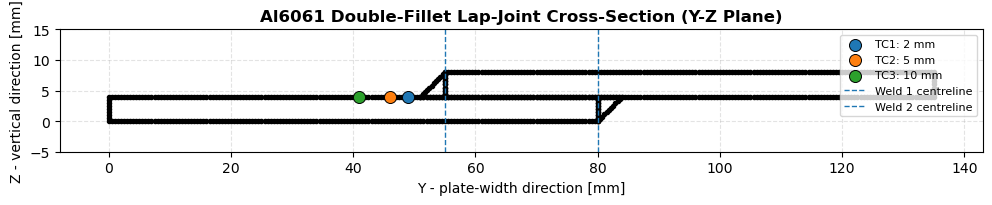

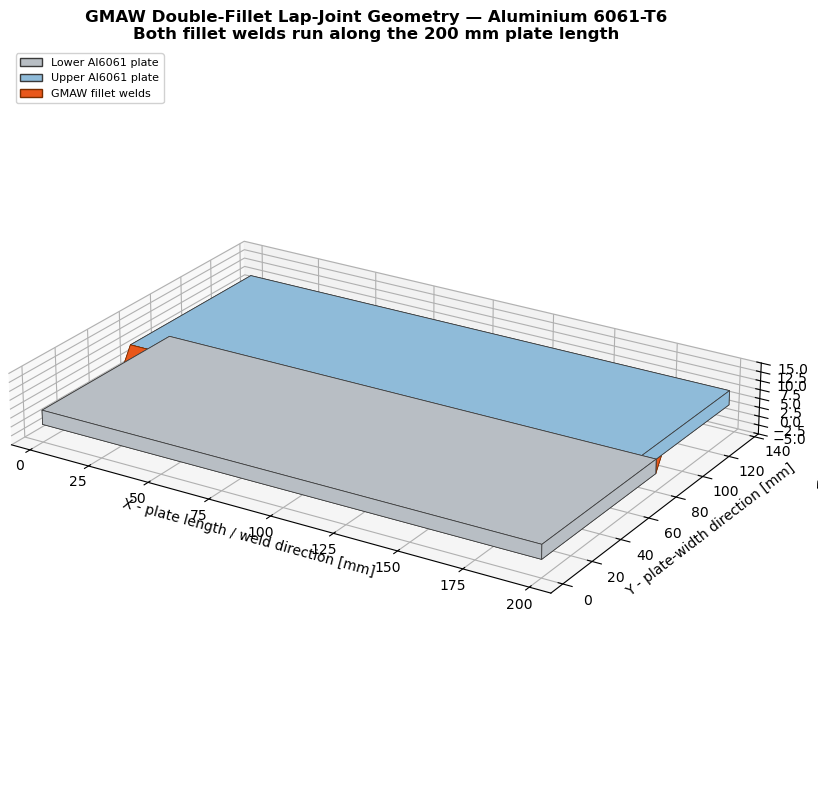


Weld-Path Information
  Travel Speed          : 8.000 mm/s
  Weld Length per Pass  : 200.0 mm
  Duration per Pass     : 25.000 s
  Total for Two Passes  : 50.000 s


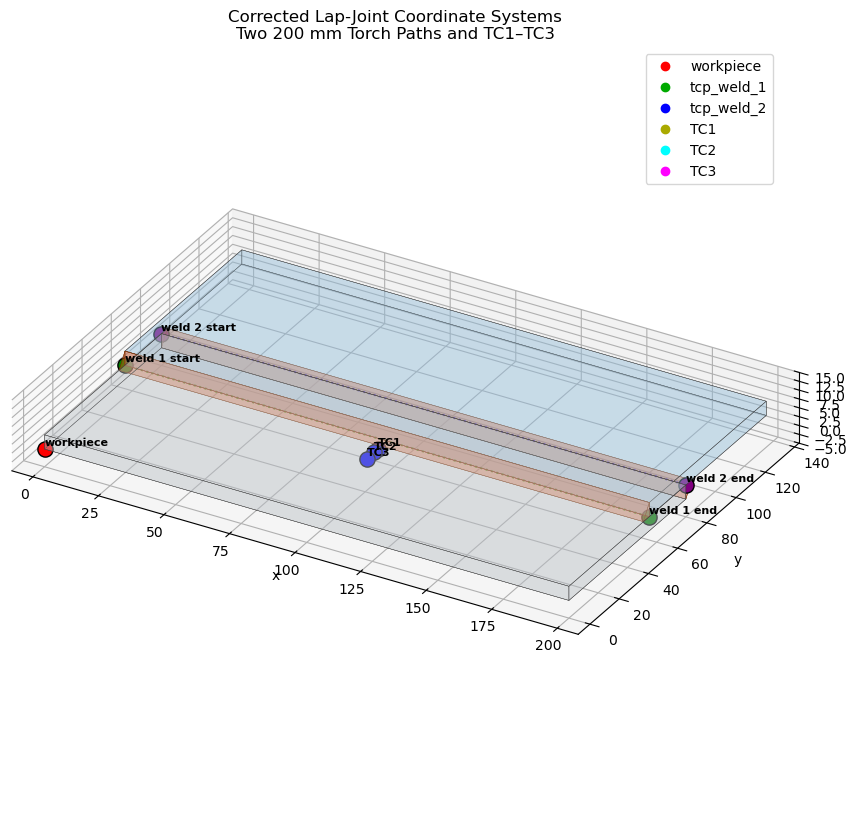

Output()


Thermocouple Locations
  TC1: 2.0 mm from the Weld 1 toe, position = (100.0, 49.0, 4.0) mm
  TC2: 5.0 mm from the Weld 1 toe, position = (100.0, 46.0, 4.0) mm
  TC3: 10.0 mm from the Weld 1 toe, position = (100.0, 41.0, 4.0) mm


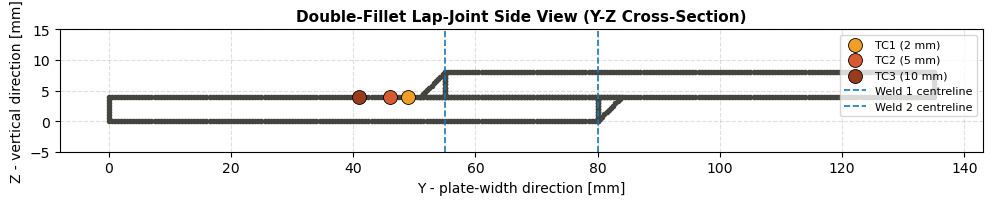


Sensor and torch positions saved to sensor_positions.csv
  Sample Interval       : 3.0 s
  Weld Length per Pass  : 200.0 mm
  Duration per Weld     : 25.000 s
  Total Two-Weld Time   : 50.000 s
  Time Steps per Weld   : 9
  Total Records         : 54

Corrected core geometry saved to project_core.asdf
Tab 3 completed successfully.
Both weld paths run along the full 200 mm plate length, and TC1 is 2 mm from the end of the Weld 1 leg.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import weldx.geometry as geo
from weldx import WeldxFile, Q_
from weldx.transformations import (
    CoordinateSystemManager,
    LocalCoordinateSystem as LCS,
)

from matplotlib.patches import Patch
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from IPython.display import display


# ============================================================
# PROJECT FILE
# ============================================================
CORE_FILE = "project_core.asdf"

if not Path(CORE_FILE).exists():
    raise FileNotFoundError(
        f"⚠ {CORE_FILE} not found. "
        "Run corrected Tab 1 and then Tab 2 first!"
    )

warnings.filterwarnings(
    "ignore",
    message=".*compat.*no_conflicts.*",
)


# ============================================================
# CLEANUP OLD OUTPUT FILES
# ============================================================
old_images = [
    "tjoint_profile.png",
    "tjoint_isometric.png",
    "tjoint_csm.png",
    "tjoint_sideview.png",
    "lapjoint_profile.png",
    "lapjoint_isometric.png",
    "lapjoint_csm.png",
    "lapjoint_sideview.png",
]

removed = 0

for image_name in old_images:
    image_path = Path(image_name)

    if image_path.exists():
        image_path.unlink()
        removed += 1

plt.close("all")

print(
    f"Cleared {removed} old image file(s) "
    "before regenerating."
)


# ============================================================
# LOAD THE CORRECTED CORE MODEL
# ============================================================
with WeldxFile(CORE_FILE, mode="r") as wx:
    core = wx.copy()

geometry_core = core["geometry"]
material_name = str(
    core["material"]["common_name"]
)


# ============================================================
# EXTRACT CORRECTED LAP-JOINT PARAMETERS
# ============================================================
plate_length_mm = float(
    geometry_core["plate_length"].to("mm").m
)

plate_width_mm = float(
    geometry_core["plate_width"].to("mm").m
)

plate_thickness_mm = float(
    geometry_core["plate_thickness"].to("mm").m
)

assembly_length_mm = float(
    geometry_core["assembly_length"].to("mm").m
)

assembly_width_mm = float(
    geometry_core["assembly_width"].to("mm").m
)

overlap_mm = float(
    geometry_core["overlap"].to("mm").m
)

fillet_leg_mm = float(
    geometry_core["fillet_leg"].to("mm").m
)

weld_length_mm = float(
    geometry_core["weld_length"].to("mm").m
)

weld_line_y_mm = np.asarray(
    geometry_core["weld_line_y_positions"].to("mm").m,
    dtype=float,
)

weld_path_1_start_mm = np.asarray(
    geometry_core["weld_path_1_start"].to("mm").m,
    dtype=float,
)

weld_path_1_end_mm = np.asarray(
    geometry_core["weld_path_1_end"].to("mm").m,
    dtype=float,
)

weld_path_2_start_mm = np.asarray(
    geometry_core["weld_path_2_start"].to("mm").m,
    dtype=float,
)

weld_path_2_end_mm = np.asarray(
    geometry_core["weld_path_2_end"].to("mm").m,
    dtype=float,
)

lower_x_range_mm = np.asarray(
    geometry_core["lower_plate_x_range"].to("mm").m,
    dtype=float,
)

lower_y_range_mm = np.asarray(
    geometry_core["lower_plate_y_range"].to("mm").m,
    dtype=float,
)

upper_x_range_mm = np.asarray(
    geometry_core["upper_plate_x_range"].to("mm").m,
    dtype=float,
)

upper_y_range_mm = np.asarray(
    geometry_core["upper_plate_y_range"].to("mm").m,
    dtype=float,
)

sensor_labels = [
    str(label)
    for label in geometry_core["sensor_labels"]
]

sensor_distances_mm = np.asarray(
    geometry_core["thermo_distance"].to("mm").m,
    dtype=float,
)

sensor_x_mm = np.asarray(
    geometry_core["thermocouple_x_positions"].to("mm").m,
    dtype=float,
)

sensor_y_mm = np.asarray(
    geometry_core["thermocouple_y_positions"].to("mm").m,
    dtype=float,
)

sensor_z_mm = np.asarray(
    geometry_core["thermocouple_z_positions"].to("mm").m,
    dtype=float,
)


# ============================================================
# VERIFY THE REQUIRED ORIENTATION AND DIMENSIONS
# ============================================================
expected_dimensions = {
    "plate length": (
        plate_length_mm,
        200.0,
    ),
    "plate width": (
        plate_width_mm,
        80.0,
    ),
    "plate thickness": (
        plate_thickness_mm,
        4.0,
    ),
    "overlap": (
        overlap_mm,
        25.0,
    ),
    "fillet leg": (
        fillet_leg_mm,
        4.0,
    ),
    "weld length": (
        weld_length_mm,
        200.0,
    ),
    "assembly length": (
        assembly_length_mm,
        200.0,
    ),
    "assembly width": (
        assembly_width_mm,
        135.0,
    ),
}

for name, (
    actual_value,
    expected_value,
) in expected_dimensions.items():
    if not np.isclose(
        actual_value,
        expected_value,
        rtol=0.0,
        atol=1.0e-9,
    ):
        raise ValueError(
            f"Unexpected {name}: {actual_value} mm. "
            f"Expected {expected_value} mm."
        )

if geometry_core["weld_travel_direction"] != "+x":
    raise ValueError(
        "Corrected Tab 3 requires the weld-travel direction to be +x."
    )

if len(weld_line_y_mm) != 2:
    raise ValueError(
        "Exactly two longitudinal weld lines are required."
    )

if not np.allclose(
    weld_line_y_mm,
    np.array(
        [
            55.0,
            80.0,
        ]
    ),
    rtol=0.0,
    atol=1.0e-9,
):
    raise ValueError(
        "The two weld lines must be located at "
        "Y = 55 mm and Y = 80 mm."
    )

if len(sensor_labels) != 3:
    raise ValueError(
        "Exactly three thermocouples are required."
    )

if not np.allclose(
    sensor_distances_mm,
    np.array(
        [
            2.0,
            5.0,
            10.0,
        ]
    ),
    rtol=0.0,
    atol=1.0e-9,
):
    raise ValueError(
        "Thermocouple distances must be 2 mm, 5 mm and 10 mm."
    )


print("\nCorrected Lap-Joint Geometry")

print(
    f"  Material              : {material_name}"
)

print(
    f"  Lower Plate           : "
    f"{plate_length_mm:.1f} × "
    f"{plate_width_mm:.1f} × "
    f"{plate_thickness_mm:.1f} mm"
)

print(
    f"  Upper Plate           : "
    f"{plate_length_mm:.1f} × "
    f"{plate_width_mm:.1f} × "
    f"{plate_thickness_mm:.1f} mm"
)

print(
    f"  Assembly Length       : "
    f"{assembly_length_mm:.1f} mm"
)

print(
    f"  Assembly Width        : "
    f"{assembly_width_mm:.1f} mm"
)

print(
    f"  Overlap Across Width  : "
    f"{overlap_mm:.1f} mm"
)

print(
    f"  Fillet Leg            : "
    f"{fillet_leg_mm:.1f} mm"
)

print(
    f"  Weld Direction        : +x"
)

print(
    f"  Weld Length per Pass  : "
    f"{weld_length_mm:.1f} mm"
)

print(
    f"  Weld-Line Y Positions : "
    f"{weld_line_y_mm} mm"
)

print(
    f"  Sensor Distances      : "
    f"{sensor_distances_mm} mm"
)


# ============================================================
# Y-Z LAP-JOINT CROSS-SECTION
# ============================================================
# Lower plate:
#   Y = 0 ... 80 mm
#   Z = 0 ... 4 mm
#
# Upper plate:
#   Y = 55 ... 135 mm
#   Z = 4 ... 8 mm
#
# Both shapes are extruded along X from 0 ... 200 mm.
#
# Weld 1:
#   Y = 55 mm, X = 0 ... 200 mm
#
# Weld 2:
#   Y = 80 mm, X = 0 ... 200 mm

lower_y_start_mm = float(
    lower_y_range_mm[0]
)

lower_y_end_mm = float(
    lower_y_range_mm[1]
)

upper_y_start_mm = float(
    upper_y_range_mm[0]
)

upper_y_end_mm = float(
    upper_y_range_mm[1]
)

weld_1_y_mm = float(
    weld_line_y_mm[0]
)

weld_2_y_mm = float(
    weld_line_y_mm[1]
)


lower_plate_yz = np.array(
    [
        [
            lower_y_start_mm,
            0.0,
        ],
        [
            lower_y_end_mm,
            0.0,
        ],
        [
            lower_y_end_mm,
            plate_thickness_mm,
        ],
        [
            lower_y_start_mm,
            plate_thickness_mm,
        ],
        [
            lower_y_start_mm,
            0.0,
        ],
    ],
    dtype=float,
)

upper_plate_yz = np.array(
    [
        [
            upper_y_start_mm,
            plate_thickness_mm,
        ],
        [
            upper_y_end_mm,
            plate_thickness_mm,
        ],
        [
            upper_y_end_mm,
            2.0 * plate_thickness_mm,
        ],
        [
            upper_y_start_mm,
            2.0 * plate_thickness_mm,
        ],
        [
            upper_y_start_mm,
            plate_thickness_mm,
        ],
    ],
    dtype=float,
)

# ------------------------------------------------------------
# CORRECT OPPOSING FILLET-WELD ORIENTATION
# ------------------------------------------------------------
# Weld 1 is placed at the exposed LEFT thickness edge of the
# upper plate (Y = 55 mm).
#
# Its vertical leg/neck follows the upper-plate thickness edge:
#     (Y, Z) = (55, 4) to (55, 8)
#
# Its horizontal leg rests on the top surface of the lower plate:
#     (Y, Z) = (51, 4) to (55, 4)
#
# Therefore, Weld 1 points outward toward decreasing Y.
weld_1_yz = np.array(
    [
        [
            weld_1_y_mm - fillet_leg_mm,
            plate_thickness_mm,
        ],
        [
            weld_1_y_mm,
            plate_thickness_mm,
        ],
        [
            weld_1_y_mm,
            plate_thickness_mm
            + fillet_leg_mm,
        ],
        [
            weld_1_y_mm - fillet_leg_mm,
            plate_thickness_mm,
        ],
    ],
    dtype=float,
)


# Weld 2 is placed at the exposed RIGHT thickness edge of the
# lower plate (Y = 80 mm).
#
# Its vertical leg/neck follows the lower-plate thickness edge:
#     (Y, Z) = (80, 0) to (80, 4)
#
# Its horizontal leg contacts the underside of the upper plate:
#     (Y, Z) = (80, 4) to (84, 4)
#
# Therefore, Weld 2 points outward toward increasing Y.
weld_2_yz = np.array(
    [
        [
            weld_2_y_mm,
            plate_thickness_mm
            - fillet_leg_mm,
        ],
        [
            weld_2_y_mm,
            plate_thickness_mm,
        ],
        [
            weld_2_y_mm
            + fillet_leg_mm,
            plate_thickness_mm,
        ],
        [
            weld_2_y_mm,
            plate_thickness_mm
            - fillet_leg_mm,
        ],
    ],
    dtype=float,
)


# Validate that both fillet welds face the correct exposed
# plate-thickness edges.
expected_weld_1_yz = np.array(
    [
        [
            upper_y_start_mm - fillet_leg_mm,
            plate_thickness_mm,
        ],
        [
            upper_y_start_mm,
            plate_thickness_mm,
        ],
        [
            upper_y_start_mm,
            2.0 * plate_thickness_mm,
        ],
        [
            upper_y_start_mm - fillet_leg_mm,
            plate_thickness_mm,
        ],
    ],
    dtype=float,
)

expected_weld_2_yz = np.array(
    [
        [
            lower_y_end_mm,
            0.0,
        ],
        [
            lower_y_end_mm,
            plate_thickness_mm,
        ],
        [
            lower_y_end_mm + fillet_leg_mm,
            plate_thickness_mm,
        ],
        [
            lower_y_end_mm,
            0.0,
        ],
    ],
    dtype=float,
)

if not np.allclose(
    weld_1_yz,
    expected_weld_1_yz,
    rtol=0.0,
    atol=1.0e-9,
):
    raise ValueError(
        "Weld 1 is not facing the exposed upper-plate "
        "thickness edge correctly."
    )

if not np.allclose(
    weld_2_yz,
    expected_weld_2_yz,
    rtol=0.0,
    atol=1.0e-9,
):
    raise ValueError(
        "Weld 2 is not facing the exposed lower-plate "
        "thickness edge correctly."
    )


# ============================================================
# THERMOCOUPLES MEASURED FROM THE END OF THE WELD LEG
# ============================================================
# Weld 1 is used as the thermocouple reference weld.
#
# Weld 1 vertical plate edge:
#   Y = 55 mm
#
# Weld 1 horizontal leg:
#   Y = 51 mm to 55 mm
#
# The outer end of the horizontal weld leg (weld toe) is:
#   Y = 51 mm
#
# TC1, TC2 and TC3 are positioned 2 mm, 5 mm and 10 mm
# away from this weld toe, toward decreasing Y.
#
# Therefore:
#   TC1 = 51 - 2  = 49 mm
#   TC2 = 51 - 5  = 46 mm
#   TC3 = 51 - 10 = 41 mm

weld_1_toe_y_mm = (
    weld_1_y_mm
    - fillet_leg_mm
)

sensor_x_mm = np.full(
    len(sensor_labels),
    plate_length_mm / 2.0,
    dtype=float,
)

sensor_y_mm = (
    weld_1_toe_y_mm
    - sensor_distances_mm
)

sensor_z_mm = np.full(
    len(sensor_labels),
    plate_thickness_mm,
    dtype=float,
)


# Verify the thermocouple distances from the weld toe.
calculated_toe_distances_mm = (
    weld_1_toe_y_mm
    - sensor_y_mm
)

if not np.allclose(
    calculated_toe_distances_mm,
    sensor_distances_mm,
    rtol=0.0,
    atol=1.0e-9,
):
    raise ValueError(
        "Thermocouple positions are not measured correctly "
        "from the end of the Weld 1 leg."
    )

if not np.isclose(
    weld_1_toe_y_mm
    - sensor_y_mm[0],
    2.0,
    rtol=0.0,
    atol=1.0e-9,
):
    raise ValueError(
        "TC1 must be exactly 2 mm from the end "
        "of the Weld 1 leg."
    )


print("\nThermocouple Reference")

print(
    f"  Weld 1 plate edge     : "
    f"Y = {weld_1_y_mm:.1f} mm"
)

print(
    f"  Weld 1 leg length     : "
    f"{fillet_leg_mm:.1f} mm"
)

print(
    f"  Weld 1 toe/end        : "
    f"Y = {weld_1_toe_y_mm:.1f} mm"
)

for (
    label,
    distance_mm,
    x_value,
    y_value,
    z_value,
) in zip(
    sensor_labels,
    sensor_distances_mm,
    sensor_x_mm,
    sensor_y_mm,
    sensor_z_mm,
):
    print(
        f"  {label}: "
        f"{distance_mm:.1f} mm from weld toe, "
        f"position = "
        f"({x_value:.1f}, "
        f"{y_value:.1f}, "
        f"{z_value:.1f}) mm"
    )


# ============================================================
# WELDX GEOMETRY PROFILE
# ============================================================
lower_shape = geo.Shape().add_line_segments(
    Q_(
        lower_plate_yz,
        "mm",
    )
)

upper_shape = geo.Shape().add_line_segments(
    Q_(
        upper_plate_yz,
        "mm",
    )
)

weld_1_shape = geo.Shape().add_line_segments(
    Q_(
        weld_1_yz,
        "mm",
    )
)

weld_2_shape = geo.Shape().add_line_segments(
    Q_(
        weld_2_yz,
        "mm",
    )
)

profile = geo.Profile(
    [
        lower_shape,
        upper_shape,
        weld_1_shape,
        weld_2_shape,
    ]
)


# ============================================================
# CROSS-SECTION PLOT
# ============================================================
fig_profile, ax_profile = plt.subplots(
    figsize=(
        10,
        5,
    )
)

profile.plot(
    ax=ax_profile,
    raster_width=Q_(
        0.5,
        "mm",
    ),
    color="black",
)

for (
    label,
    distance_mm,
    y_value,
    z_value,
) in zip(
    sensor_labels,
    sensor_distances_mm,
    sensor_y_mm,
    sensor_z_mm,
):
    ax_profile.scatter(
        y_value,
        z_value,
        s=75,
        edgecolors="black",
        linewidths=0.7,
        zorder=20,
        label=(
            f"{label}: "
            f"{distance_mm:.0f} mm"
        ),
    )

ax_profile.axvline(
    weld_1_y_mm,
    linestyle="--",
    linewidth=1.0,
    label="Weld 1 centreline",
)

ax_profile.axvline(
    weld_2_y_mm,
    linestyle="--",
    linewidth=1.0,
    label="Weld 2 centreline",
)

ax_profile.set_title(
    "Al6061 Double-Fillet Lap-Joint "
    "Cross-Section (Y-Z Plane)",
    fontweight="bold",
)

ax_profile.set_xlabel(
    "Y - plate-width direction [mm]"
)

ax_profile.set_ylabel(
    "Z - vertical direction [mm]"
)

ax_profile.set_xlim(
    -8.0,
    assembly_width_mm + 8.0,
)

ax_profile.set_ylim(
    -5.0,
    2.0 * plate_thickness_mm + 7.0,
)

ax_profile.set_aspect(
    "equal",
    adjustable="box",
)

ax_profile.grid(
    True,
    linestyle="--",
    alpha=0.35,
)

ax_profile.legend(
    fontsize=8,
    loc="upper right",
)

plt.tight_layout()

plt.savefig(
    "lapjoint_profile.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# MANUAL 3D PRISM GENERATION
# ============================================================
def prism_faces_from_yz(
    polygon_yz,
    x_start,
    x_end,
):
    """
    Extrude a closed Y-Z polygon along the global X direction.
    """

    polygon_yz = np.asarray(
        polygon_yz,
        dtype=float,
    )

    if np.allclose(
        polygon_yz[0],
        polygon_yz[-1],
    ):
        polygon_yz = polygon_yz[:-1]

    front = [
        (
            x_start,
            y_value,
            z_value,
        )
        for y_value, z_value
        in polygon_yz
    ]

    back = [
        (
            x_end,
            y_value,
            z_value,
        )
        for y_value, z_value
        in polygon_yz
    ]

    faces = [
        front[::-1],
        back,
    ]

    point_count = len(
        polygon_yz
    )

    for index in range(
        point_count
    ):
        next_index = (
            index + 1
        ) % point_count

        y_0, z_0 = polygon_yz[
            index
        ]

        y_1, z_1 = polygon_yz[
            next_index
        ]

        faces.append(
            [
                (
                    x_start,
                    y_0,
                    z_0,
                ),
                (
                    x_end,
                    y_0,
                    z_0,
                ),
                (
                    x_end,
                    y_1,
                    z_1,
                ),
                (
                    x_start,
                    y_1,
                    z_1,
                ),
            ]
        )

    return faces


LOWER_PLATE_COLOR = "#B8BEC4"
UPPER_PLATE_COLOR = "#8FBBD9"
WELD_COLOR = "#E8571A"

PLATE_EDGE_COLOR = "#3A3A3A"
WELD_EDGE_COLOR = "#7A2E00"

solid_definitions = [
    (
        "Lower plate",
        lower_plate_yz,
        LOWER_PLATE_COLOR,
        PLATE_EDGE_COLOR,
    ),
    (
        "Upper plate",
        upper_plate_yz,
        UPPER_PLATE_COLOR,
        PLATE_EDGE_COLOR,
    ),
    (
        "Weld 1",
        weld_1_yz,
        WELD_COLOR,
        WELD_EDGE_COLOR,
    ),
    (
        "Weld 2",
        weld_2_yz,
        WELD_COLOR,
        WELD_EDGE_COLOR,
    ),
]


# ============================================================
# 3D ISOMETRIC LAP-JOINT PLOT
# ============================================================
fig_iso = plt.figure(
    figsize=(
        15,
        8,
    )
)

ax_iso = fig_iso.add_subplot(
    111,
    projection="3d",
)

for (
    solid_name,
    polygon_yz,
    face_color,
    edge_color,
) in solid_definitions:
    faces = prism_faces_from_yz(
        polygon_yz=polygon_yz,
        x_start=0.0,
        x_end=plate_length_mm,
    )

    collection = Poly3DCollection(
        faces,
        facecolor=face_color,
        edgecolor=edge_color,
        linewidths=0.55,
        alpha=1.0,
    )

    ax_iso.add_collection3d(
        collection
    )


# Two weld paths run along the full 200 mm length.
ax_iso.plot(
    [
        0.0,
        plate_length_mm,
    ],
    [
        weld_1_y_mm,
        weld_1_y_mm,
    ],
    [
        plate_thickness_mm,
        plate_thickness_mm,
    ],
    color=WELD_EDGE_COLOR,
    linestyle="--",
    linewidth=2.0,
    label="Weld path 1: 200 mm",
)

ax_iso.plot(
    [
        0.0,
        plate_length_mm,
    ],
    [
        weld_2_y_mm,
        weld_2_y_mm,
    ],
    [
        plate_thickness_mm,
        plate_thickness_mm,
    ],
    color="#702963",
    linestyle="--",
    linewidth=2.0,
    label="Weld path 2: 200 mm",
)


for (
    label,
    distance_mm,
    x_value,
    y_value,
    z_value,
) in zip(
    sensor_labels,
    sensor_distances_mm,
    sensor_x_mm,
    sensor_y_mm,
    sensor_z_mm,
):
    ax_iso.scatter(
        x_value,
        y_value,
        z_value,
        s=95,
        edgecolors="black",
        linewidths=0.8,
        zorder=20,
    )

    ax_iso.text(
        x_value,
        y_value,
        z_value + 1.0,
        (
            f"{label}\n"
            f"{distance_mm:.0f} mm"
        ),
        fontsize=8,
        fontweight="bold",
        ha="center",
    )


ax_iso.set_title(
    f"GMAW Double-Fillet Lap-Joint Geometry — "
    f"{material_name}\n"
    "Both fillet welds run along the 200 mm plate length",
    fontweight="bold",
)

ax_iso.set_xlabel(
    "X - plate length / weld direction [mm]"
)

ax_iso.set_ylabel(
    "Y - plate-width direction [mm]"
)

ax_iso.set_zlabel(
    "Z - vertical direction [mm]"
)

ax_iso.set_xlim(
    -8.0,
    plate_length_mm + 8.0,
)

ax_iso.set_ylim(
    -8.0,
    assembly_width_mm + 8.0,
)

ax_iso.set_zlim(
    -5.0,
    2.0 * plate_thickness_mm + 7.0,
)

ax_iso.set_box_aspect(
    (
        plate_length_mm,
        assembly_width_mm,
        25.0,
    )
)

ax_iso.view_init(
    elev=24,
    azim=-58,
)

legend_elements = [
    Patch(
        facecolor=LOWER_PLATE_COLOR,
        edgecolor=PLATE_EDGE_COLOR,
        label="Lower Al6061 plate",
    ),
    Patch(
        facecolor=UPPER_PLATE_COLOR,
        edgecolor=PLATE_EDGE_COLOR,
        label="Upper Al6061 plate",
    ),
    Patch(
        facecolor=WELD_COLOR,
        edgecolor=WELD_EDGE_COLOR,
        label="GMAW fillet welds",
    ),
]

ax_iso.legend(
    handles=legend_elements,
    loc="upper left",
    fontsize=8,
    framealpha=0.9,
)

plt.tight_layout()

plt.savefig(
    "lapjoint_isometric.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# WELD SPEED AND CORRECTED WELD DURATIONS
# ============================================================
v_weld_mm_s = float(
    core["process"]["speed"].to("mm/s").m
)

weld_duration_per_pass_s = (
    weld_length_mm
    / v_weld_mm_s
)

total_weld_duration_s = (
    2.0
    * weld_duration_per_pass_s
)


print("\nWeld-Path Information")

print(
    f"  Travel Speed          : "
    f"{v_weld_mm_s:.3f} mm/s"
)

print(
    f"  Weld Length per Pass  : "
    f"{weld_length_mm:.1f} mm"
)

print(
    f"  Duration per Pass     : "
    f"{weld_duration_per_pass_s:.3f} s"
)

print(
    f"  Total for Two Passes  : "
    f"{total_weld_duration_s:.3f} s"
)


# ============================================================
# COORDINATE SYSTEM MANAGER
# ============================================================
csm = CoordinateSystemManager(
    "base"
)

csm.add_cs(
    "workpiece",
    "base",
    LCS(
        coordinates=Q_(
            [
                0.0,
                0.0,
                0.0,
            ],
            "mm",
        )
    ),
)


time_start = pd.Timedelta(
    seconds=0.0
)

time_end = pd.Timedelta(
    seconds=weld_duration_per_pass_s
)

tcp_weld_1 = LCS(
    coordinates=Q_(
        np.vstack(
            [
                weld_path_1_start_mm,
                weld_path_1_end_mm,
            ]
        ),
        "mm",
    ),
    time=[
        time_start,
        time_end,
    ],
)

tcp_weld_2 = LCS(
    coordinates=Q_(
        np.vstack(
            [
                weld_path_2_start_mm,
                weld_path_2_end_mm,
            ]
        ),
        "mm",
    ),
    time=[
        time_start,
        time_end,
    ],
)

csm.add_cs(
    "tcp_weld_1",
    "workpiece",
    tcp_weld_1,
)

csm.add_cs(
    "tcp_weld_2",
    "workpiece",
    tcp_weld_2,
)


sensor_points = {}

for (
    label,
    x_value,
    y_value,
    z_value,
) in zip(
    sensor_labels,
    sensor_x_mm,
    sensor_y_mm,
    sensor_z_mm,
):
    point = [
        float(x_value),
        float(y_value),
        float(z_value),
    ]

    csm.add_cs(
        label,
        "workpiece",
        LCS(
            coordinates=Q_(
                point,
                "mm",
            )
        ),
    )

    sensor_points[
        label
    ] = point


# ============================================================
# CSM PLOT WITH CORRECTED LAP-JOINT OVERLAY
# ============================================================
try:
    ax_csm = csm.plot(
        coordinate_systems=[
            "workpiece",
            "tcp_weld_1",
            "tcp_weld_2",
            *sensor_labels,
        ],
        reference_system="workpiece",
        show_vectors=False,
        title=(
            "Corrected Lap-Joint Coordinate Systems\n"
            "Two 200 mm Torch Paths and TC1–TC3"
        ),
    )

    for (
        solid_name,
        polygon_yz,
        face_color,
        edge_color,
    ) in solid_definitions:
        faces = prism_faces_from_yz(
            polygon_yz=polygon_yz,
            x_start=0.0,
            x_end=plate_length_mm,
        )

        ax_csm.add_collection3d(
            Poly3DCollection(
                faces,
                facecolor=face_color,
                edgecolor=edge_color,
                linewidths=0.30,
                alpha=0.25,
            )
        )

    overlay_points = {
        "workpiece": (
            [
                0.0,
                0.0,
                0.0,
            ],
            "red",
        ),
        "weld 1 start": (
            weld_path_1_start_mm.tolist(),
            "green",
        ),
        "weld 1 end": (
            weld_path_1_end_mm.tolist(),
            "green",
        ),
        "weld 2 start": (
            weld_path_2_start_mm.tolist(),
            "purple",
        ),
        "weld 2 end": (
            weld_path_2_end_mm.tolist(),
            "purple",
        ),
    }

    for label, point in sensor_points.items():
        overlay_points[
            label
        ] = (
            point,
            "blue",
        )

    for (
        label,
        (
            point,
            point_color,
        ),
    ) in overlay_points.items():
        ax_csm.scatter(
            *point,
            color=point_color,
            s=120,
            edgecolors="black",
            linewidths=1.0,
            zorder=100,
        )

        ax_csm.text(
            point[0],
            point[1],
            point[2] + 1.0,
            label,
            fontsize=8,
            fontweight="bold",
            zorder=101,
        )

    ax_csm.set_xlim(
        -8.0,
        plate_length_mm + 8.0,
    )

    ax_csm.set_ylim(
        -8.0,
        assembly_width_mm + 8.0,
    )

    ax_csm.set_zlim(
        -5.0,
        2.0 * plate_thickness_mm + 7.0,
    )

    ax_csm.set_box_aspect(
        (
            plate_length_mm,
            assembly_width_mm,
            25.0,
        )
    )

    plt.savefig(
        "lapjoint_csm.png",
        dpi=150,
        bbox_inches="tight",
    )

    plt.show()

except Exception as csm_error:
    print(
        "\nCoordinate-system matplotlib plot skipped:"
    )

    print(
        f"  {type(csm_error).__name__}: "
        f"{csm_error}"
    )


# ============================================================
# OPTIONAL INTERACTIVE K3D VIEW
# ============================================================
try:
    plot_k3d = csm.plot(
        backend="k3d",
        coordinate_systems=[
            "workpiece",
            "tcp_weld_1",
            "tcp_weld_2",
            *sensor_labels,
        ],
        reference_system="workpiece",
        show_vectors=False,
        show_origins=True,
    )

    display(
        plot_k3d
    )

except Exception as k3d_error:
    print(
        "\nInteractive k3d view skipped:"
    )

    print(
        f"  {type(k3d_error).__name__}: "
        f"{k3d_error}"
    )


# ============================================================
# THERMOCOUPLE LOCATION SUMMARY
# ============================================================
print("\nThermocouple Locations")

sensor_positions = []

for (
    label,
    distance_mm,
    x_value,
    y_value,
    z_value,
) in zip(
    sensor_labels,
    sensor_distances_mm,
    sensor_x_mm,
    sensor_y_mm,
    sensor_z_mm,
):
    position = {
        "label": label,
        "distance_from_weld_1_mm": float(
            distance_mm
        ),
        "x_mm": float(
            x_value
        ),
        "y_mm": float(
            y_value
        ),
        "z_mm": float(
            z_value
        ),
    }

    sensor_positions.append(
        position
    )

    print(
        f"  {label}: "
        f"{distance_mm:.1f} mm from the Weld 1 toe, "
        f"position = "
        f"({x_value:.1f}, "
        f"{y_value:.1f}, "
        f"{z_value:.1f}) mm"
    )


# ============================================================
# Y-Z SIDE VIEW
# ============================================================
thermocouple_colors = [
    "#EF9F27",
    "#D85A30",
    "#993C1D",
]

fig_side, ax_side = plt.subplots(
    figsize=(
        10,
        5,
    )
)

profile.plot(
    ax=ax_side,
    raster_width=Q_(
        0.5,
        "mm",
    ),
    color="#444441",
)

for (
    y_value,
    z_value,
    label,
    distance_mm,
    point_color,
) in zip(
    sensor_y_mm,
    sensor_z_mm,
    sensor_labels,
    sensor_distances_mm,
    thermocouple_colors,
):
    ax_side.scatter(
        y_value,
        z_value,
        color=point_color,
        s=100,
        edgecolors="black",
        linewidths=0.6,
        zorder=10,
        label=(
            f"{label} "
            f"({distance_mm:.0f} mm)"
        ),
    )

ax_side.axvline(
    weld_1_y_mm,
    linestyle="--",
    linewidth=1.2,
    label="Weld 1 centreline",
)

ax_side.axvline(
    weld_2_y_mm,
    linestyle="--",
    linewidth=1.2,
    label="Weld 2 centreline",
)

ax_side.set_title(
    "Double-Fillet Lap-Joint Side View "
    "(Y-Z Cross-Section)",
    fontsize=11,
    fontweight="bold",
)

ax_side.set_xlabel(
    "Y - plate-width direction [mm]"
)

ax_side.set_ylabel(
    "Z - vertical direction [mm]"
)

ax_side.set_xlim(
    -8.0,
    assembly_width_mm + 8.0,
)

ax_side.set_ylim(
    -5.0,
    2.0 * plate_thickness_mm + 7.0,
)

ax_side.legend(
    loc="upper right",
    fontsize=8,
    frameon=True,
)

ax_side.grid(
    True,
    linestyle="--",
    alpha=0.4,
)

ax_side.set_aspect(
    "equal",
    adjustable="box",
)

plt.tight_layout()

plt.savefig(
    "lapjoint_sideview.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()


# ============================================================
# TIME-RESOLVED SENSOR AND TORCH POSITIONS
# ============================================================
TC_SAMPLE_INTERVAL_S = 3.0

time_samples_s = np.arange(
    0.0,
    weld_duration_per_pass_s
    + TC_SAMPLE_INTERVAL_S,
    TC_SAMPLE_INTERVAL_S,
)

time_samples_s = time_samples_s[
    time_samples_s
    <= weld_duration_per_pass_s
]

torch_x_samples_mm = (
    v_weld_mm_s
    * time_samples_s
)


sensor_positions_time_series = []

weld_definitions = [
    {
        "weld_id": 1,
        "weld_y_mm": weld_1_y_mm,
        "global_time_offset_s": 0.0,
    },
    {
        "weld_id": 2,
        "weld_y_mm": weld_2_y_mm,
        "global_time_offset_s": weld_duration_per_pass_s,
    },
]

for weld_definition in weld_definitions:
    weld_id = weld_definition[
        "weld_id"
    ]

    weld_y_mm = weld_definition[
        "weld_y_mm"
    ]

    global_time_offset_s = weld_definition[
        "global_time_offset_s"
    ]

    for (
        local_time_s,
        torch_x_mm,
    ) in zip(
        time_samples_s,
        torch_x_samples_mm,
    ):
        global_time_s = (
            global_time_offset_s
            + local_time_s
        )

        for sensor in sensor_positions:
            sensor_positions_time_series.append(
                {
                    "label": sensor[
                        "label"
                    ],
                    "distance_from_weld_1_mm": (
                        sensor[
                            "distance_from_weld_1_mm"
                        ]
                    ),
                    "sensor_x_mm": sensor[
                        "x_mm"
                    ],
                    "sensor_y_mm": sensor[
                        "y_mm"
                    ],
                    "sensor_z_mm": sensor[
                        "z_mm"
                    ],
                    "weld_id": weld_id,
                    "local_t_s": round(
                        float(
                            local_time_s
                        ),
                        3,
                    ),
                    "global_t_s": round(
                        float(
                            global_time_s
                        ),
                        3,
                    ),
                    "torch_x_mm": round(
                        float(
                            torch_x_mm
                        ),
                        3,
                    ),
                    "torch_y_mm": round(
                        float(
                            weld_y_mm
                        ),
                        3,
                    ),
                    "torch_z_mm": round(
                        float(
                            plate_thickness_mm
                        ),
                        3,
                    ),
                }
            )


sensor_dataframe = pd.DataFrame(
    sensor_positions_time_series
)

csv_path = "sensor_positions.csv"

sensor_dataframe.to_csv(
    csv_path,
    index=False,
)


print(
    f"\nSensor and torch positions saved to {csv_path}"
)

print(
    f"  Sample Interval       : "
    f"{TC_SAMPLE_INTERVAL_S:.1f} s"
)

print(
    f"  Weld Length per Pass  : "
    f"{weld_length_mm:.1f} mm"
)

print(
    f"  Duration per Weld     : "
    f"{weld_duration_per_pass_s:.3f} s"
)

print(
    f"  Total Two-Weld Time   : "
    f"{total_weld_duration_s:.3f} s"
)

print(
    f"  Time Steps per Weld   : "
    f"{len(time_samples_s)}"
)

print(
    f"  Total Records         : "
    f"{len(sensor_positions_time_series)}"
)


# ============================================================
# SAVE EXTENDED GEOMETRY TO PROJECT_CORE.ASDF
# ============================================================
geometry_extended = dict(
    core["geometry"]
)

# Compatibility aliases point to Weld 1.
geometry_extended[
    "weld_path_start"
] = Q_(
    weld_path_1_start_mm,
    "mm",
)

geometry_extended[
    "weld_path_end"
] = Q_(
    weld_path_1_end_mm,
    "mm",
)

geometry_extended[
    "weld_duration"
] = Q_(
    weld_duration_per_pass_s,
    "s",
)

geometry_extended[
    "weld_duration_per_pass"
] = Q_(
    weld_duration_per_pass_s,
    "s",
)

geometry_extended[
    "total_weld_duration"
] = Q_(
    total_weld_duration_s,
    "s",
)

geometry_extended[
    "tc_sample_interval"
] = Q_(
    TC_SAMPLE_INTERVAL_S,
    "s",
)

geometry_extended[
    "thermocouple_reference"
] = {
    "reference_weld": "Weld 1",
    "reference_feature": (
        "Outer end/toe of the 4 mm horizontal fillet-weld leg"
    ),
    "weld_plate_edge_y": Q_(
        weld_1_y_mm,
        "mm",
    ),
    "weld_toe_y": Q_(
        weld_1_toe_y_mm,
        "mm",
    ),
    "distance_direction": "-y",
}

geometry_extended[
    "thermocouple_x_positions"
] = Q_(
    sensor_x_mm,
    "mm",
)

geometry_extended[
    "thermocouple_y_positions"
] = Q_(
    sensor_y_mm,
    "mm",
)

geometry_extended[
    "thermocouple_z_positions"
] = Q_(
    sensor_z_mm,
    "mm",
)

geometry_extended[
    "sensor_distances"
] = {
    "values": sensor_distances_mm.tolist(),
    "unit": "mm",
    "reference": (
        "Distance from the outer end/toe of the Weld 1 "
        "horizontal fillet-weld leg"
    ),
}

geometry_extended[
    "sensor_positions_reference"
] = {
    "file": csv_path,
    "description": (
        "Fixed thermocouple positions and time-resolved "
        "torch positions for two sequential 200 mm GMAW "
        "fillet-weld paths. The weld-travel direction is +x. "
        "TC1, TC2 and TC3 are 2 mm, 5 mm and 10 mm "
        "from the end of the Weld 1 leg."
    ),
    "columns": list(
        sensor_dataframe.columns
    ),
    "record_count": len(
        sensor_positions_time_series
    ),
}

geometry_extended[
    "fillet_weld_orientation"
] = {
    "weld_1": (
        "Vertical leg on exposed upper-plate thickness edge "
        "at Y = 55 mm; horizontal leg on top of lower plate; "
        "weld faces toward decreasing Y."
    ),
    "weld_2": (
        "Vertical leg on exposed lower-plate thickness edge "
        "at Y = 80 mm; horizontal leg under upper plate; "
        "weld faces toward increasing Y."
    ),
}

geometry_extended[
    "geometry_output_images"
] = {
    "profile": (
        "lapjoint_profile.png"
    ),
    "isometric": (
        "lapjoint_isometric.png"
    ),
    "coordinate_systems": (
        "lapjoint_csm.png"
    ),
    "side_view": (
        "lapjoint_sideview.png"
    ),
}


with WeldxFile(
    CORE_FILE,
    mode="rw",
) as wx:
    wx["geometry"] = (
        geometry_extended
    )


print(
    f"\nCorrected core geometry saved to {CORE_FILE}"
)

print(
    "Tab 3 completed successfully."
)

print(
    "Both weld paths run along the full 200 mm plate length, "
    "and TC1 is 2 mm from the end of the Weld 1 leg."
)